In [2]:
pip install iso3166

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from iso3166 import countries
from matplotlib.ticker import MaxNLocator

# read raw data
df = pd.read_csv("API_SP.POP.TOTL_DS2_en_csv_v2_19373.csv", skiprows=4)

In [4]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN,NaN


In [5]:
# select 2023 data and rename columns
df2023 = df[['Country Name', 'Country Code', '2023']] \
    .dropna(subset=['2023']) \
    .rename(columns={
        "Country Name":"country", 
        "Country Code":"iso3", 
        "2023":"pop_2023"
    })

# Build a set of valid ISO-3166 alpha-3 country codes
valid_iso3 = {c.alpha3 for c in countries}

# Keep only rows whose code is in the valid country list
df_countries_2023 = df2023[df2023['iso3'].isin(valid_iso3)]

In [6]:
df_countries_2023.head()

,country,iso3,pop_2023
0,Aruba,ABW,107359.0
2,Afghanistan,AFG,41454761.0
4,Angola,AGO,36749906.0
5,Albania,ALB,2745972.0
6,Andorra,AND,80856.0


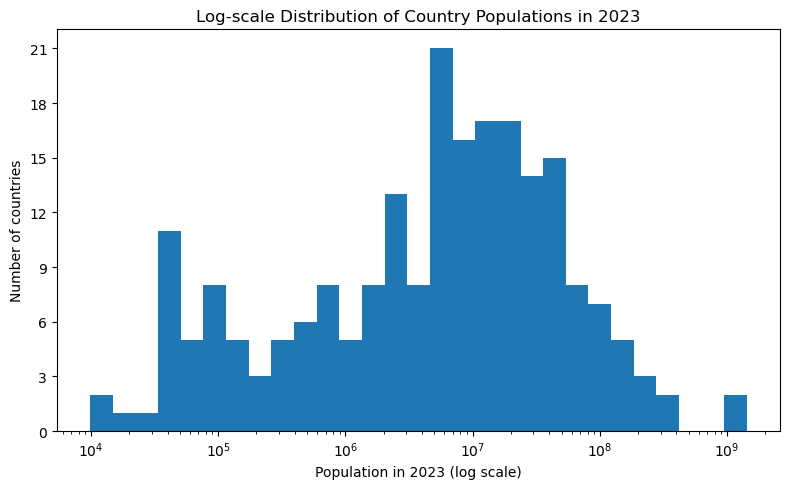

In [7]:
# Plot the distribution of country populations in 2023

fig, ax = plt.subplots(figsize=(8,5))

# Use a log scale on x-axis to better display wide-ranging values
ax.hist(
    df_countries_2023['pop_2023'], 
    bins=np.logspace(np.log10(df_countries_2023['pop_2023'].min()), np.log10(df_countries_2023['pop_2023'].max()), 30)
)
ax.set_xscale('log')
ax.set_xlabel('Population in 2023 (log scale)')
ax.set_ylabel('Number of countries')
ax.set_title('Log-scale Distribution of Country Populations in 2023')

# Force y-axis ticks to integer values
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

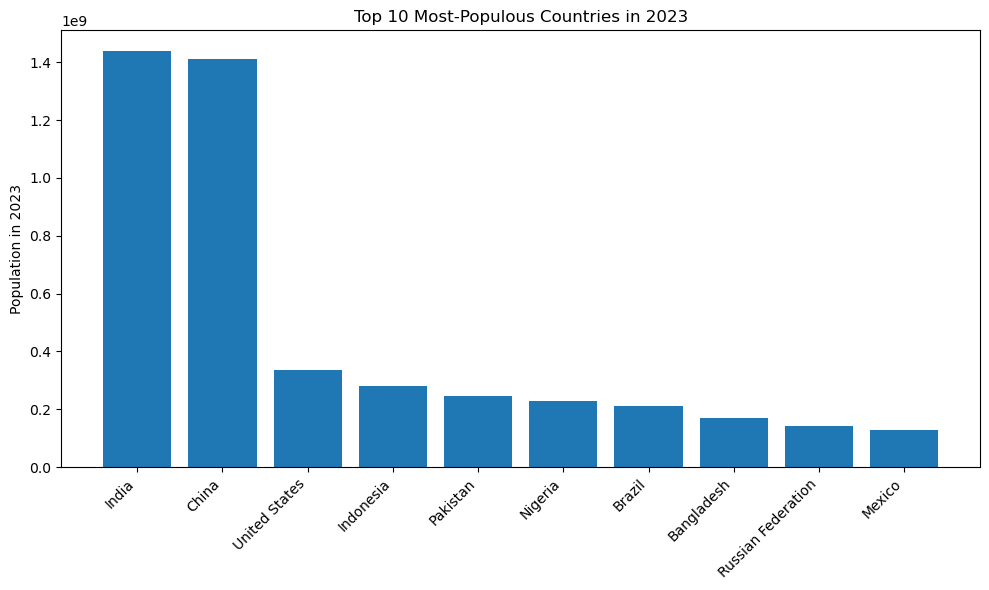

In [8]:
# Plot the top 10 most populous countries in 2023

top10 = df_countries_2023.sort_values('pop_2023', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['country'], top10['pop_2023'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Population in 2023')
plt.title('Top 10 Most-Populous Countries in 2023')
plt.tight_layout()
plt.show()